#**Exercise.**
##**Implement an End to End CNN Model for Image Classification Task.**

In [1]:
import os
import random
import zipfile
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

from sklearn.metrics import classification_report

In [2]:
zip_path = "/content/drive/MyDrive/AI&ML/Copy of FruitinAmazon.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Corrected base_dir to point to the extracted content
base_dir = "/content/FruitinAmazon"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

print("Train path:", train_dir)
print("Test path:", test_dir)

Train path: /content/FruitinAmazon/train
Test path: /content/FruitinAmazon/test


## Task 1: Data understanding and visualization

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


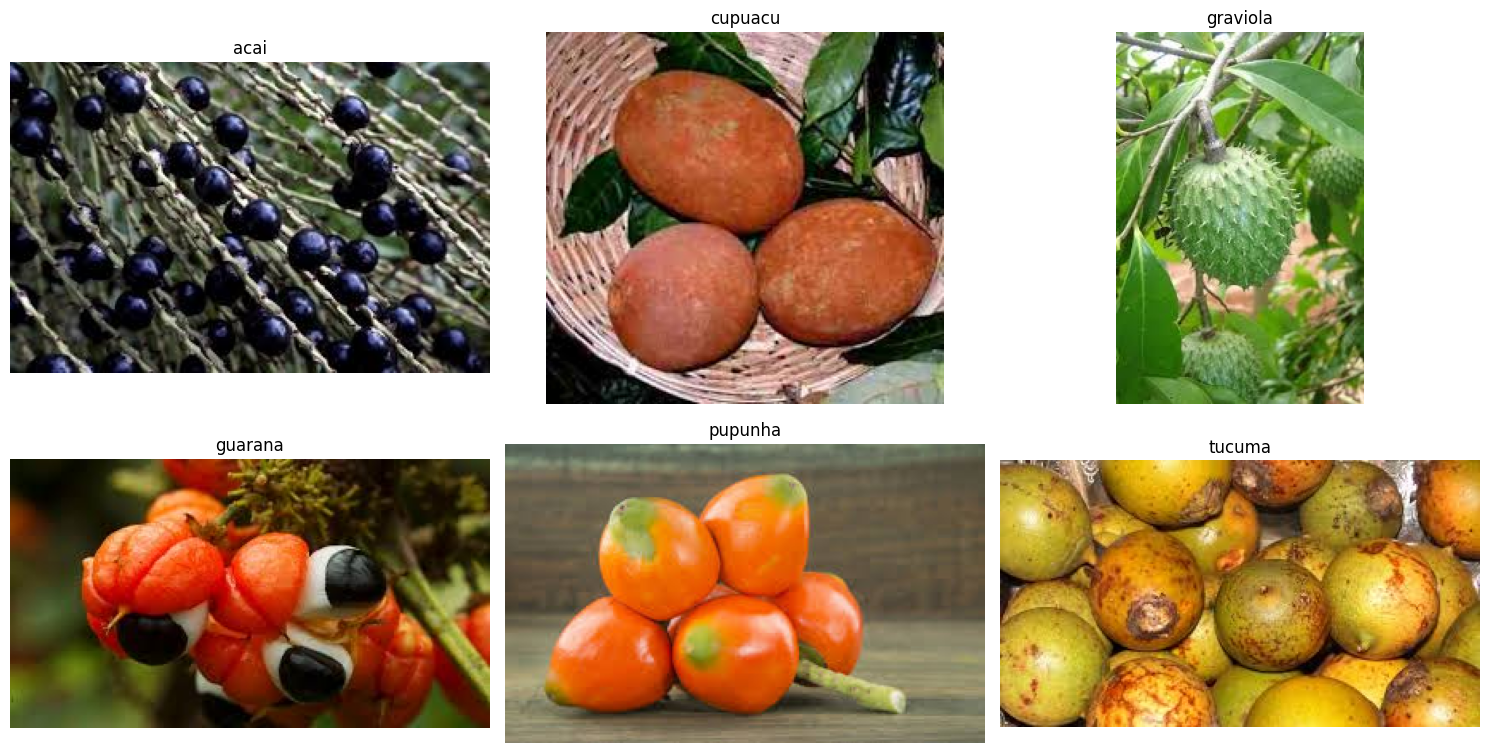

In [3]:
class_names = sorted([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))])
print("Classes:", class_names)

sample_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    chosen = random.choice(images)
    sample_images.append((class_name, os.path.join(class_path, chosen)))

plt.figure(figsize=(15, 8))

for i, (class_name, img_path) in enumerate(sample_images):
    plt.subplot(2, 3, i + 1)
    img = Image.open(img_path)
    plt.imshow(img)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

##2: Check corrupted images

In [4]:
corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                img.verify()
        except (IOError, SyntaxError, OSError):
            corrupted_images.append(image_path)
            os.remove(image_path)
            print(f"Removed corrupted image: {image_path}")

if len(corrupted_images) == 0:
    print("No Corrupted Images Found.")

No Corrupted Images Found.


## Task 2: Load and preprocess image data

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.

Verifying raw dataset batch before rescaling
  Image batch shape: (16, 128, 128, 3)
  Label batch shape: (16,)
  Image data type: <dtype: 'float32'>
  Image pixel value range (example first image): 0.0579071044921875 - 255.0
  First 5 labels in batch: [1 0 5 4 4]


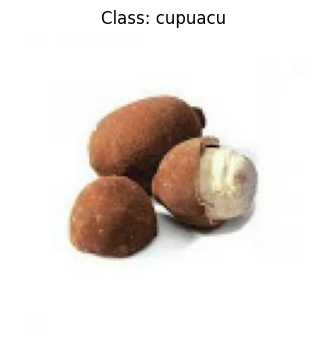

End raw dataset verification 

Classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


In [7]:
img_height = 128
img_width = 128
batch_size = 16
validation_split = 0.2
seed = 123

rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=seed
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    batch_size=batch_size,
    shuffle=False
)

class_names = train_ds.class_names

# --- Verification before mapping ---
print("\nVerifying raw dataset batch before rescaling")
for image_batch, labels_batch in train_ds.take(1):
    print(f"  Image batch shape: {image_batch.shape}")
    print(f"  Label batch shape: {labels_batch.shape}")
    print(f"  Image data type: {image_batch.dtype}")
    print(f"  Image pixel value range (example first image): {image_batch[0].numpy().min()} - {image_batch[0].numpy().max()}")
    print(f"  First 5 labels in batch: {labels_batch.numpy()[:5]}")

    # Display one image to verify (should be 0-255)
    plt.figure(figsize=(4, 4))
    plt.imshow(image_batch[0].numpy().astype("uint8"))
    plt.title(f"Class: {class_names[labels_batch[0].numpy()]}")
    plt.axis("off")
    plt.show()
print("End raw dataset verification \n")
# --- End Verification before mapping ---

train_ds = train_ds.map(lambda x, y: (rescale(x), y))
val_ds = val_ds.map(lambda x, y: (rescale(x), y))
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

num_classes = len(class_names)

print("Classes:", class_names)
print("Number of classes:", num_classes)

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## Task 3: Build the CNN model

In [9]:
model = keras.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Conv2D(32, (3, 3), strides=1, padding='same', activation='relu'),
    layers.MaxPooling2D((2, 2), strides=2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,116,454 (8.07 MB)

 Trainable params: 2,116,454 (8.07 MB)

 Non-trainable params: 0 (0.00 B)

## Task 4: Compile the model

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

##Train the Model

In [13]:
checkpoint = ModelCheckpoint(
    "best_fruit_model.h5",
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=250,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 245ms/step - accuracy: 0.0979 - loss: 1.9653
Epoch 1: val_accuracy improved from None to 0.11111, saving model to best_fruit_model.h5



Epoch 1: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 355ms/step - accuracy: 0.1250 - loss: 1.9560 - val_accuracy: 0.1111 - val_loss: 1.7657
Epoch 2/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy: 0.3319 - loss: 1.7465
Epoch 2: val_accuracy improved from 0.11111 to 0.38889, saving model to best_fruit_model.h5



Epoch 2: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step - accuracy: 0.3056 - loss: 1.7298 - val_accuracy: 0.3889 - val_loss: 1.6676
Epoch 3/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 418ms/step - accuracy: 0.4073 - loss: 1.5435
Epoch 3: val_accuracy did not improve from 0.38889
5/5 ━━━━━━━━━━━━━━━━━━━━ 4s 500ms/step - accuracy: 0.4583 - loss: 1.5195 - val_accuracy: 0.3889 - val_loss: 1.5495
Epoch 4/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step - accuracy: 0.5792 - loss: 1.1903
Epoch 4: val_accuracy improved from 0.38889 to 0.66667, saving model to best_fruit_model.h5



Epoch 4: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 419ms/step - accuracy: 0.6667 - loss: 1.1344 - val_accuracy: 0.6667 - val_loss: 1.0432
Epoch 5/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.6625 - loss: 0.8000
Epoch 5: val_accuracy improved from 0.66667 to 0.77778, saving model to best_fruit_model.h5



Epoch 5: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 287ms/step - accuracy: 0.7500 - loss: 0.7671 - val_accuracy: 0.7778 - val_loss: 0.6392
Epoch 6/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step - accuracy: 0.8128 - loss: 0.5282
Epoch 6: val_accuracy improved from 0.77778 to 0.83333, saving model to best_fruit_model.h5



Epoch 6: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step - accuracy: 0.8194 - loss: 0.5353 - val_accuracy: 0.8333 - val_loss: 0.4872
Epoch 7/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.8295 - loss: 0.5324
Epoch 7: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 265ms/step - accuracy: 0.8611 - loss: 0.4817 - val_accuracy: 0.6111 - val_loss: 0.7249
Epoch 8/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.8997 - loss: 0.2473
Epoch 8: val_accuracy did not improve from 0.83333
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 268ms/step - accuracy: 0.9306 - loss: 0.2244 - val_accuracy: 0.8333 - val_loss: 0.4989
Epoch 9/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.9024 - loss: 0.2364
Epoch 9: val_accuracy improved from 0.83333 to 0.94444, saving model to best_fruit_model.h5



Epoch 9: finished saving model to best_fruit_model.h5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 274ms/step - accuracy: 0.9028 - loss: 0.2247 - val_accuracy: 0.9444 - val_loss: 0.3115
Epoch 10/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step - accuracy: 0.9740 - loss: 0.1513
Epoch 10: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step - accuracy: 0.9583 - loss: 0.1878 - val_accuracy: 0.8333 - val_loss: 0.3320
Epoch 11/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.9941 - loss: 0.0563
Epoch 11: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 429ms/step - accuracy: 0.9861 - loss: 0.0700 - val_accuracy: 0.8889 - val_loss: 0.4221
Epoch 12/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 1.0000 - loss: 0.0386
Epoch 12: val_accuracy did not improve from 0.94444
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 438ms/step - accuracy: 1.0000 - loss: 0.0282 - val_accuracy: 0.8333 - val_loss: 0.3626
Epoch 13/250
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step - accuracy: 1.0000 

## Plot training and validation graphs

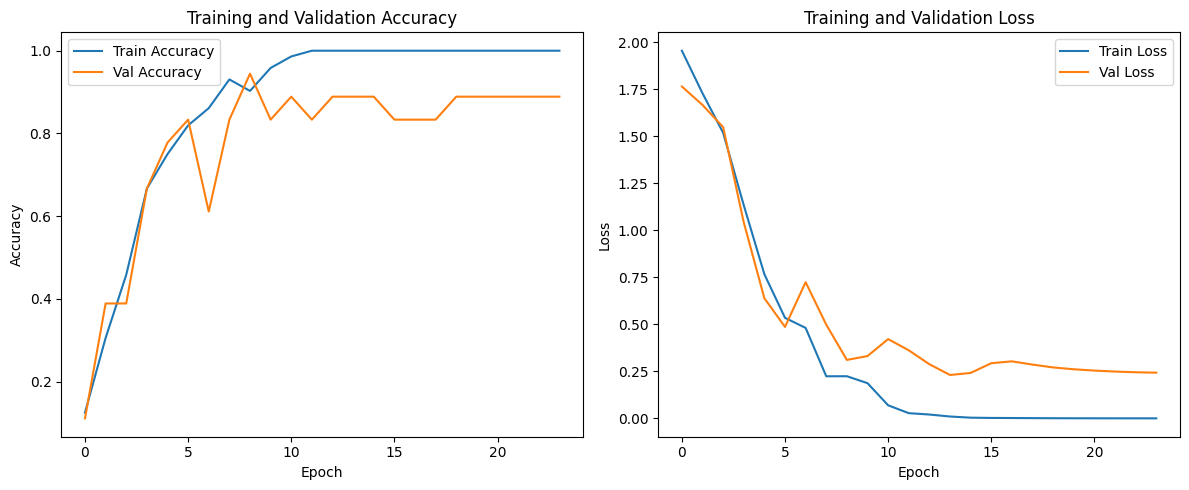

In [14]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

## Task 5: Evaluate on test set

In [15]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.8667 - loss: 0.6769
Test Loss: 0.676948606967926
Test Accuracy: 0.8666666746139526


## Task 6: Save and load the model

In [17]:
model.save("fruit_classifier_model.h5")
print("Model saved successfully.")
loaded_model = keras.models.load_model("fruit_classifier_model.h5")
loaded_loss, loaded_acc = loaded_model.evaluate(test_ds)

print("Loaded Model Test Loss:", loaded_loss)
print("Loaded Model Test Accuracy:", loaded_acc)

Model saved successfully.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.8667 - loss: 0.6769
Loaded Model Test Loss: 0.676948606967926
Loaded Model Test Accuracy: 0.8666666746139526


## Task 7: Predictions and classification report

In [18]:
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = loaded_model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
Classification Report:

              precision    recall  f1-score   support

        acai       0.83      1.00      0.91         5
     cupuacu       0.62      1.00      0.77         5
    graviola       1.00      0.80      0.89         5
     guarana       1.00      1.00      1.00         5
     pupunha       1.00      1.00      1.00         5
      tucuma       1.00      0.40      0.57         5

    accuracy                           0.87        30
   macro avg       0.91      0.87      0.86        30
weighted avg       0.91      0.87      0.86        30

